In [1]:
# pip install tiktoken matplotlib

In [2]:
import torch
import tiktoken
from configs.model import ModelConfig
from configs.training import TrainingConfig
from configs.scheduler import SchedulerConfig
from configs.optimizer import OptimizerConfig
from configs.checkpoint import CheckpointConfig
from models.deepseek import DeepSeek
from datasets.preprocess import download_the_verdict,train_val_dataloader
from evaluation.losses import cross_entropy_loss,token_accuracy
from trainer.trainer import Trainer

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
tokenizer = tiktoken.get_encoding("gpt2")

In [4]:
DeepSeek_SMALL = ModelConfig(
    emb_dim=96,
    expert_dim=24,
    n_layers=12,
    n_heads=4,
    activation="gelu",
    context_length=24,
    latent_dim=48
)

TRAIN_CONFIG = TrainingConfig(
    epoch=5,
    batch_size=2,
    stride=24,
    context_length=24
)

OPTIMIZER_CONFIG = OptimizerConfig()
SCHEDULER_CONFIG = SchedulerConfig()
CHECKPOINT_CONFIG = CheckpointConfig()


In [5]:
raw_text = download_the_verdict()
train_dataloader,val_dataloader = train_val_dataloader(raw_text, TRAIN_CONFIG)

TrainingConfig(epoch=5, batch_size=2, stride=24, context_length=24, learning_rate=0.0003, weight_decay=0.1, grad_clip=1.0, mixed_precision=False, shuffle=False, num_workers=0, drop_last=True, gradient_accumulation_steps=1, train_data_ratio=0.9)
TrainingConfig(epoch=5, batch_size=2, stride=24, context_length=24, learning_rate=0.0003, weight_decay=0.1, grad_clip=1.0, mixed_precision=False, shuffle=False, num_workers=0, drop_last=True, gradient_accumulation_steps=1, train_data_ratio=0.9)


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [7]:
model = DeepSeek(DeepSeek_SMALL).to(device)

In [8]:
trainer=Trainer(model,tokenizer,train_dataloader,val_dataloader,device,cross_entropy_loss,token_accuracy,CHECKPOINT_CONFIG,TRAIN_CONFIG,OPTIMIZER_CONFIG,SCHEDULER_CONFIG)

In [9]:
trainer.fit()           ### use arg resume_latest=True or resume_best=True to resume training

100%|██████████| 96/96 [00:44<00:00,  2.14it/s]


Checkpoint saved -> checkpoints\checkpoint_96.pt
Best checkpoint saved -> checkpoints\best_checkpoint.pt
Output text:
 Every effort moves youpt
after 1 epoch global step 96 the train loss 10.397418846686682 val loss 9.303354263305664 and train acc| 0.019314236434487004 val acc| 0.03598484769463539 


100%|██████████| 96/96 [00:54<00:00,  1.77it/s]


Checkpoint saved -> checkpoints\checkpoint_192.pt
Best checkpoint saved -> checkpoints\best_checkpoint.pt
Output text:
 Every effort moves you var
after 2 epoch global step 192 the train loss 7.471548606952031 val loss 7.403587818145752 and train acc| 0.05208333374078696 val acc| 0.04545454680919647 


100%|██████████| 96/96 [01:01<00:00,  1.57it/s]


Checkpoint saved -> checkpoints\checkpoint_288.pt
Best checkpoint saved -> checkpoints\best_checkpoint.pt
Output text:
 Every effort moves you ab
after 3 epoch global step 288 the train loss 6.257610251506169 val loss 7.056442737579346 and train acc| 0.0750868057560486 val acc| 0.05303030088543892 


100%|██████████| 96/96 [00:47<00:00,  2.01it/s]


Checkpoint saved -> checkpoints\checkpoint_384.pt
Best checkpoint saved -> checkpoints\best_checkpoint.pt
Output text:
 Every effort moves youDestroy
after 4 epoch global step 384 the train loss 6.011169388890266 val loss 6.799056529998779 and train acc| 0.08138020866317675 val acc| 0.05113637074828148 


100%|██████████| 96/96 [00:45<00:00,  2.12it/s]


Checkpoint saved -> checkpoints\checkpoint_480.pt
Best checkpoint saved -> checkpoints\best_checkpoint.pt
Output text:
 Every effort moves you yellow
after 5 epoch global step 480 the train loss 5.832935030261676 val loss 6.588159561157227 and train acc| 0.09657118058142562 val acc| 0.0624999962747097 


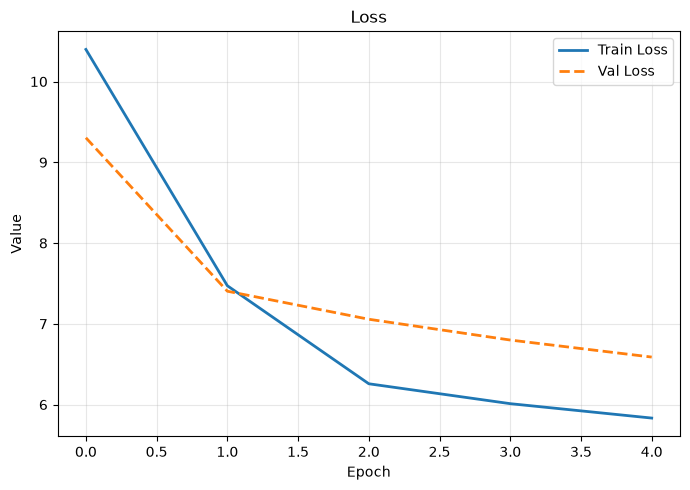

In [12]:
trainer.metrics.plot("train_loss","val_loss")

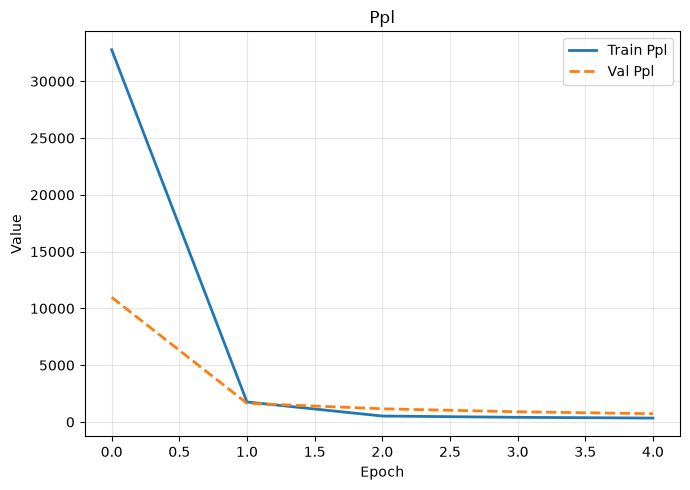

In [13]:
trainer.metrics.plot("train_ppl","val_ppl")

In [14]:
trainer.metrics.metrics

defaultdict(list,
            {'train_loss': [10.397418846686682,
              7.471548606952031,
              6.257610251506169,
              6.011169388890266,
              5.832935030261676],
             'train_acc': [0.019314236434487004,
              0.05208333374078696,
              0.0750868057560486,
              0.08138020866317675,
              0.09657118058142562],
             'train_ppl': [32774.91930984478,
              1757.3259867073798,
              521.9700712694937,
              407.9601054609165,
              341.35910952329755],
             'val_loss': [9.303354263305664,
              7.403587818145752,
              7.056442737579346,
              6.799056529998779,
              6.588159561157227],
             'val_acc': [0.03598484769463539,
              0.04545454680919647,
              0.05303030088543892,
              0.05113637074828148,
              0.0624999962747097],
             'val_ppl': [10974.769805765283,
              1641.864